# Sinc
The impulse response $h_\text{LP}$ defined by the sinc-function is given by

$h_\text{LP}(t)=\text{sinc} \left( 2f_c t \right)=\frac{\sin\left(\pi 2f_c t\right)}{\pi 2f_c t}$

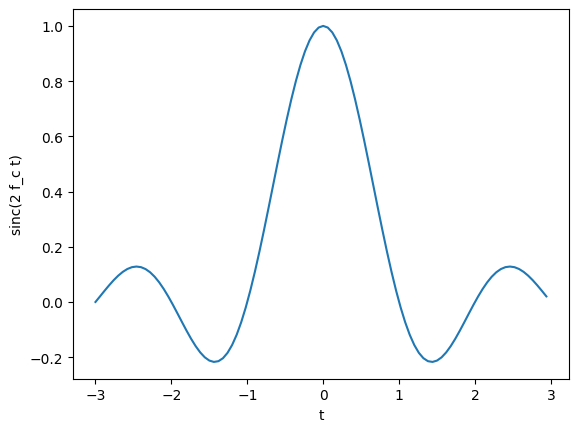

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fc = 0.5
t = np.arange(100) / 100 * 6 - 3

plt.plot(t, np.sinc(2*fc*t))
plt.xlabel('t')
plt.ylabel('sinc(2 f_c t)')
plt.show()

The sinc-function corresponds to the impulse response of the ideal lowpass filter with cutoff frequency $f_c$.

Signals with frequencies below this cutoff frequency $f_c$ will pass the lowpass filter without any reasonable damping.

Signals with frequencies above this cutoff frequency $f_c$ will be affected by strong damping.

In [2]:
r = 16000
fc = r/4

t = np.arange(r) / r
f = np.random.rand(1) * r / 2
x = np.sin(2*np.pi*f*t)

h = np.sinc(2*fc*t - fc)
h /= np.sum(h**2)
h *= np.sqrt(2)

y = np.convolve(x, h)

def Power(x):
    return np.mean(x**2)

if f < fc:
    assert np.abs(Power(x) - Power(y)) < 1e-3, 'for frequencies below cutoff frequency, the power should be preserved'
else:
    assert Power(y) < 1e-3, 'for frequencies above cutoff frequency, the power should be negligible'